# SecureFedHE — Ring 2: Selective Homomorphic Encryption

**Project:** Privacy-Preserving Federated Learning with Selective HE  
**Phase:** 3 — Ring 2 (Selective HE layer on top of vanilla FL baseline)  
**Prerequisite:** Ring 1 baseline already ran locally — best accuracy **79.43%**

---

### What this notebook does
1. Installs all dependencies (including TenSEAL — Linux only, works on Colab)
2. Builds the full project structure in-memory
3. Validates the HE context before training
4. Runs Ring 2 training with Selective CKKS encryption on fc2
5. Saves all metrics + model weights to Google Drive

### How to use
- **Runtime → Change runtime type → T4 GPU** (top right, free tier)
- Run cells top to bottom with **Shift+Enter**
- Do NOT skip the validation cell (Cell 4)

---

In [ ]:
# ── Install all packages ───────────────────────────────────────────────────
!pip install tenseal flwr --quiet

# Torch, numpy, etc. are pre-installed on Colab — just verify
import torch, numpy, flwr, tenseal
print(f'torch     : {torch.__version__}')
print(f'tenseal   : {tenseal.__version__}')
print(f'flwr      : {flwr.__version__}')
print(f'GPU       : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NOT available — go to Runtime > Change runtime type > T4"}')
print()
print('✓ All packages installed.')

torch     : 2.10.0+cu128
tenseal   : 0.3.16
flwr      : 1.29.0
GPU       : Tesla T4

✓ All packages installed.


## Cell 2 — Mount Google Drive
Your metrics CSV and model weights will be saved here so you don't lose them when Colab resets.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/SecureFedHE/evaluation/logs'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save directory: {SAVE_DIR}')
print('✓ Google Drive mounted.')

Mounted at /content/drive
Save directory: /content/drive/MyDrive/SecureFedHE/evaluation/logs
✓ Google Drive mounted.


## Cell 3 — Project Code
All modules are defined here. This replaces the file structure you have locally.

## Cell 1 — Install Dependencies
⏱ Takes ~2 minutes on first run. Output will be long — scroll to the end and confirm no errors.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# models/cnn.py
# ════════════════════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    """
    3-block CNN for CIFAR-10.
    fc2 (final classifier) is the HE encryption target.
    fc1 (intermediate) gets Differential Privacy noise.
    conv blocks are transmitted in plaintext.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32),
            nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),
            nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128),
            nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(128*4*4, 256)   # ← DP noise target
        self.fc2 = nn.Linear(256, num_classes) # ← CKKS HE target

    def forward(self, x):
        x = self.block3(self.block2(self.block1(x)))
        x = self.dropout(x.flatten(1))
        return self.fc2(F.relu(self.fc1(x)))

print('✓ SimpleCNN defined.')

✓ SimpleCNN defined.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# data/loader.py
# ════════════════════════════════════════════════════════════════════════════
import numpy as np
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

TRAIN_TF = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))])

TEST_TF = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))])

def partition_noniid(dataset, num_clients, alpha=0.5, seed=42):
    rng = np.random.default_rng(seed)
    labels = np.array(dataset.targets)
    client_idx = [[] for _ in range(num_clients)]
    for cls in range(10):
        idx = np.where(labels == cls)[0]
        rng.shuffle(idx)
        props = rng.dirichlet(np.repeat(alpha, num_clients))
        props = (props * len(idx)).astype(int)
        props[-1] = len(idx) - props[:-1].sum()
        for i, split in enumerate(np.split(idx, np.cumsum(props[:-1]))):
            client_idx[i].extend(split.tolist())
    return client_idx

def load_datasets(num_clients=5, alpha=0.5, batch_size=32, seed=42):
    train_ds = datasets.CIFAR10('/content/data', train=True,  download=True, transform=TRAIN_TF)
    test_ds  = datasets.CIFAR10('/content/data', train=False, download=True, transform=TEST_TF)
    client_idx = partition_noniid(train_ds, num_clients, alpha, seed)
    train_loaders = [
        DataLoader(Subset(train_ds, idx), batch_size=batch_size, shuffle=True, num_workers=2)
        for idx in client_idx]
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)
    print(f'  Partition: Non-IID (α={alpha}) | Clients: {num_clients}')
    for i, idx in enumerate(client_idx):
        lbs = np.array(train_ds.targets)[idx]
        dom = np.bincount(lbs).argmax()
        print(f'  Client {i:02d}: {len(idx):>4} samples | dominant class: {dom}')
    return train_loaders, test_loader

print('✓ Data loader defined.')

✓ Data loader defined.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# evaluation/metrics.py
# ════════════════════════════════════════════════════════════════════════════
import csv, time, os
from dataclasses import dataclass, astuple, fields
import psutil

@dataclass
class RoundMetrics:
    round_num: int;      phase: str;          client_id: int
    train_loss: float;   train_acc: float
    eval_loss: float;    eval_acc: float
    comm_bytes: int;     wall_time_s: float
    cpu_pct: float;      ram_mb: float
    enc_overhead_s: float

class Profiler:
    def __init__(self, log_path):
        self.log_path = log_path
        os.makedirs(os.path.dirname(log_path), exist_ok=True)
        self._proc = psutil.Process()
        self._t0 = self._mem0 = None
        if not os.path.exists(log_path):
            with open(log_path,'w',newline='') as f:
                csv.writer(f).writerow([x.name for x in fields(RoundMetrics)])

    def start(self):
        self._proc.cpu_percent(interval=None)
        self._mem0 = self._proc.memory_info().rss/1e6
        self._t0   = time.perf_counter()

    def stop(self, round_num, phase, client_id, train_loss, train_acc,
             eval_loss, eval_acc, comm_bytes, enc_overhead_s=0.0):
        m = RoundMetrics(
            round_num, phase, client_id,
            round(train_loss,4), round(train_acc,4),
            round(eval_loss,4),  round(eval_acc,4),
            comm_bytes,
            round(time.perf_counter()-self._t0,3),
            round(self._proc.cpu_percent(interval=None),1),
            round((self._proc.memory_info().rss/1e6)-self._mem0,1),
            round(enc_overhead_s,3))
        with open(self.log_path,'a',newline='') as f:
            csv.writer(f).writerow(astuple(m))
        return m

def compute_accuracy(model, loader, device):
    model.eval()
    correct = total = loss_sum = 0
    crit = torch.nn.CrossEntropyLoss()
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            out  = model(x)
            loss_sum += crit(out,y).item()*len(y)
            correct  += (out.argmax(1)==y).sum().item()
            total    += len(y)
    return loss_sum/total, correct/total

def model_size_bytes(model):
    return sum(p.numel() for p in model.parameters()) * 4

print('✓ Profiler defined.')

✓ Profiler defined.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# crypto/he_layer.py  +  baseline/aggregator.py
# ════════════════════════════════════════════════════════════════════════════
import tenseal as ts
import copy

# ── HE Context ────────────────────────────────────────────────────────────
def create_he_context(poly_modulus_degree=8192, scale_bits=40):
    ctx = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=poly_modulus_degree,
        coeff_mod_bit_sizes=[60, scale_bits, scale_bits, 60])
    ctx.generate_galois_keys()
    ctx.global_scale = 2**scale_bits
    return ctx

# ── Encrypt / Decrypt ─────────────────────────────────────────────────────
def encrypt_fc2(params, ctx):
    enc, shapes = {}, {}
    for k in ['fc2.weight','fc2.bias']:
        shapes[k] = params[k].shape
        enc[k] = ts.ckks_vector(ctx, params[k].flatten().tolist())
    return enc, shapes

def decrypt_fc2(enc_fc2, shapes):
    return {k: np.array(enc_fc2[k].decrypt(),dtype=np.float32).reshape(shapes[k])
            for k in shapes}

# ── HE Aggregation (no decryption on server) ──────────────────────────────
def aggregate_encrypted_fc2(enc_list, sizes):
    total = sum(sizes)
    ws = [s/total for s in sizes]
    result = {}
    for k in ['fc2.weight','fc2.bias']:
        agg = enc_list[0][k] * ws[0]
        for enc,w in zip(enc_list[1:],ws[1:]):
            agg = agg + (enc[k]*w)
        result[k] = agg
    return result

# ── Differential Privacy for fc1 ──────────────────────────────────────────
def add_dp_noise(params, epsilon=2.0, delta=1e-5, sensitivity=0.1):
    sigma = sensitivity * np.sqrt(2*np.log(1.25/delta)) / epsilon
    out = dict(params)
    for k in ['fc1.weight','fc1.bias']:
        norm = np.linalg.norm(out[k])
        if norm > sensitivity:
            out[k] = out[k] * (sensitivity/norm)
        out[k] = out[k] + np.random.normal(0, sigma, out[k].shape).astype(np.float32)
    return out

# ── Plaintext FedAvg helpers ──────────────────────────────────────────────
def get_params(model):
    return {k: v.cpu().numpy() for k,v in model.state_dict().items()}

def set_params(model, params):
    model.load_state_dict(
        {k: torch.tensor(v, dtype=torch.float32) for k,v in params.items()}, strict=True)
    return model

print('✓ HE layer + aggregator defined.')

✓ HE layer + aggregator defined.


## Cell 4 — HE Validation ✅
**Run this before training.** All 6 checks must show OK.

In [ ]:
print('='*55)
print('  SecureFedHE · Ring 2 HE Validation')
print('='*55)

# 1. Import
print(f'  [1] TenSEAL import ........... OK  (v{ts.__version__})')

# 2. Context
t0 = time.perf_counter()
ctx_test = create_he_context()
print(f'  [2] Context creation ......... OK  ({time.perf_counter()-t0:.2f}s)')

# 3. Encrypt → Decrypt
orig = np.random.randn(10,256).astype(np.float32)
enc  = ts.ckks_vector(ctx_test, orig.flatten().tolist())
rec  = np.array(enc.decrypt(),dtype=np.float32).reshape(10,256)
print(f'  [3] Encrypt → Decrypt ........ OK')

# 4. Approximation error
diff = np.abs(orig - rec)
assert diff.max() < 1e-3, f'HE error too large: {diff.max():.2e}'
print(f'  [4] Approximation error ...... OK  (max={diff.max():.2e}, mean={diff.mean():.2e})')

# 5. HE aggregation
ws  = [0.4, 0.35, 0.25]
ars = [np.random.randn(10,256).astype(np.float32) for _ in range(3)]
encs= [ts.ckks_vector(ctx_test,a.flatten().tolist()) for a in ars]
exp = sum(a*w for a,w in zip(ars,ws))
agg = encs[0]*ws[0]
for e,w in zip(encs[1:],ws[1:]): agg = agg + (e*w)
got = np.array(agg.decrypt(),dtype=np.float32).reshape(10,256)
assert np.abs(exp-got).max() < 1e-3
print(f'  [5] HE aggregation ........... OK  (max_diff={np.abs(exp-got).max():.2e})')

# 6. Timing
t0 = time.perf_counter()
for _ in range(5):
    e = ts.ckks_vector(ctx_test, orig.flatten().tolist())
    _ = e.decrypt()
avg = (time.perf_counter()-t0)/5
print(f'  [6] Encryption time .......... OK  ({avg:.3f}s per encrypt+decrypt)')

print()
print('  ✓  All checks passed. Safe to run Ring 2 training.')
print('='*55)

  SecureFedHE · Ring 2 HE Validation
  [1] TenSEAL import ........... OK  (v0.3.16)
  [2] Context creation ......... OK  (0.57s)
  [3] Encrypt → Decrypt ........ OK
  [4] Approximation error ...... OK  (max=7.45e-09, mean=4.77e-11)
  [5] HE aggregation ........... OK  (max_diff=4.77e-07)
  [6] Encryption time .......... OK  (0.017s per encrypt+decrypt)

  ✓  All checks passed. Safe to run Ring 2 training.


## Cell 5 — Configuration
Change these settings before running. Default = full 20-round benchmark.

In [ ]:
# ── Training configuration ─────────────────────────────────────────────────
CONFIG = {
    'rounds'      : 20,     # FL communication rounds (use 5 for a quick test)
    'num_clients' : 5,      # Simulated edge devices
    'local_epochs': 2,      # Local training epochs per round
    'lr'          : 0.01,   # SGD learning rate
    'batch_size'  : 32,     # Local batch size
    'alpha'       : 0.5,    # Dirichlet non-IID alpha
    'fraction'    : 1.0,    # Fraction of clients selected per round
    'dp_epsilon'  : 2.0,    # DP privacy budget for fc1 (lower = stronger privacy)
    'dp_delta'    : 1e-5,
    'dp_sensitivity': 0.1,
    'he_degree'   : 8192,   # CKKS poly modulus degree
    'seed'        : 42,
    'log_path'    : f'{SAVE_DIR}/he_metrics.csv',
    'weights_path': f'{SAVE_DIR}/best_he.pth',
    'baseline_acc': 79.43,  # Your Ring 1 result — used for milestone check
}

print('Configuration:')
for k,v in CONFIG.items():
    print(f'  {k:<20}: {v}')

Configuration:
  rounds              : 20
  num_clients         : 5
  local_epochs        : 2
  lr                  : 0.01
  batch_size          : 32
  alpha               : 0.5
  fraction            : 1.0
  dp_epsilon          : 2.0
  dp_delta            : 1e-05
  dp_sensitivity      : 0.1
  he_degree           : 8192
  seed                : 42
  log_path            : /content/drive/MyDrive/SecureFedHE/evaluation/logs/he_metrics.csv
  weights_path        : /content/drive/MyDrive/SecureFedHE/evaluation/logs/best_he.pth
  baseline_acc        : 79.43


## Cell 6 — Load Data + Build HE Context
⏱ CIFAR-10 download: ~30 seconds. HE context generation: ~1–2 seconds.

In [ ]:
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}\n')

# Data
print('Loading CIFAR-10...')
train_loaders, test_loader = load_datasets(
    num_clients=CONFIG['num_clients'],
    alpha=CONFIG['alpha'],
    batch_size=CONFIG['batch_size'],
    seed=CONFIG['seed'])

# HE context
print('\nGenerating CKKS context...', end=' ', flush=True)
t0 = time.perf_counter()
HE_CTX = create_he_context(poly_modulus_degree=CONFIG['he_degree'])
print(f'done ({time.perf_counter()-t0:.2f}s)')

# Global model
global_model = SimpleCNN().to(device)
fc2_params   = sum(p.numel() for p in list(global_model.parameters())[-2:])
print(f'\nModel total params : {sum(p.numel() for p in global_model.parameters()):,}')
print(f'fc2 params (HE)    : {fc2_params:,}')
print(f'Transmission/round : {model_size_bytes(global_model)/1024:.1f} KB plaintext + encrypted fc2')
print('\n✓ Ready to train.')

Device: cuda

Loading CIFAR-10...


100%|██████████| 170M/170M [00:08<00:00, 19.0MB/s]


  Partition: Non-IID (α=0.5) | Clients: 5
  Client 00: 9623 samples | dominant class: 9
  Client 01: 9813 samples | dominant class: 2
  Client 02: 5554 samples | dominant class: 4
  Client 03: 12706 samples | dominant class: 7
  Client 04: 12304 samples | dominant class: 0

Generating CKKS context... done (0.22s)

Model total params : 620,810
fc2 params (HE)    : 2,570
Transmission/round : 2425.0 KB plaintext + encrypted fc2

✓ Ready to train.


## Cell 7 — Ring 2 Training Loop
⏱ ~3–5 minutes for 20 rounds on T4 GPU. Watch `enc_overhead` — that's your paper's key metric.

In [ ]:
profiler = Profiler(CONFIG['log_path'])
rng      = np.random.default_rng(CONFIG['seed'])
best_acc = 0.0
history  = []

print(f"{'='*70}")
print(f"  SecureFedHE · Ring 2 — Selective HE Training")
print(f"  Encrypted: fc2 (CKKS) | DP-noised: fc1 | Plaintext: conv blocks")
print(f"  DP ε={CONFIG['dp_epsilon']}, δ={CONFIG['dp_delta']}")
print(f"{'='*70}\n")

for rnd in range(1, CONFIG['rounds']+1):
    print(f'── Round {rnd:02d}/{CONFIG["rounds"]} ', end='', flush=True)

    global_params = get_params(global_model)
    k = max(1, int(CONFIG['num_clients'] * CONFIG['fraction']))
    sel_idx = rng.choice(CONFIG['num_clients'], size=k, replace=False)

    enc_fc2_list, plain_list, sizes = [], [], []
    round_losses, round_accs = [], []
    total_enc_time = 0.0
    fc2_shapes = None

    profiler.start()

    for cid in sel_idx:
        # ── Broadcast global weights to client ──────────────────────────
        set_params(global_model, global_params)
        local_model = copy.deepcopy(global_model).to(device)
        local_model.train()

        optimizer = torch.optim.SGD(local_model.parameters(),
            lr=CONFIG['lr'], momentum=0.9, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()

        # ── Local training ───────────────────────────────────────────────
        e_losses, e_accs = [], []
        for _ in range(CONFIG['local_epochs']):
            rl = correct = total = 0
            for x,y in train_loaders[cid]:
                x,y = x.to(device), y.to(device)
                optimizer.zero_grad()
                out  = local_model(x)
                loss = criterion(out,y)
                loss.backward()
                optimizer.step()
                rl      += loss.item()*len(y)
                correct += (out.argmax(1)==y).sum().item()
                total   += len(y)
            e_losses.append(rl/total)
            e_accs.append(correct/total)

        # ── Extract params ───────────────────────────────────────────────
        all_params = get_params(local_model)

        # ── Apply DP to fc1 ──────────────────────────────────────────────
        all_params = add_dp_noise(all_params,
            epsilon=CONFIG['dp_epsilon'],
            delta=CONFIG['dp_delta'],
            sensitivity=CONFIG['dp_sensitivity'])

        # ── Encrypt fc2 with CKKS ────────────────────────────────────────
        t_enc = time.perf_counter()
        enc_fc2, shapes = encrypt_fc2(all_params, HE_CTX)
        total_enc_time += time.perf_counter() - t_enc

        # ── Build plaintext dict (conv blocks + dp-noised fc1) ───────────
        plain = {k:v for k,v in all_params.items()
                 if k not in ('fc2.weight','fc2.bias')}

        enc_fc2_list.append(enc_fc2)
        plain_list.append(plain)
        sizes.append(len(train_loaders[cid].dataset))
        round_losses.append(float(np.mean(e_losses)))
        round_accs.append(float(np.mean(e_accs)))
        fc2_shapes = shapes
        print('.', end='', flush=True)

    # ── Server: aggregate encrypted fc2 (no decryption!) ────────────────
    agg_enc = aggregate_encrypted_fc2(enc_fc2_list, sizes)

    # ── Server: decrypt aggregate ────────────────────────────────────────
    dec_fc2 = decrypt_fc2(agg_enc, fc2_shapes)

    # ── Server: aggregate plaintext params ───────────────────────────────
    total_sz = sum(sizes)
    ws = [s/total_sz for s in sizes]
    agg_plain = {}
    for key in plain_list[0]:
        stk = np.stack([p[key] for p in plain_list])
        w   = np.array(ws).reshape([-1]+[1]*(stk.ndim-1))
        agg_plain[key] = (stk*w).sum(axis=0)

    # ── Server: assemble and load full model ─────────────────────────────
    full_state = {**agg_plain, **dec_fc2}
    global_model.load_state_dict(
        {k: torch.tensor(v,dtype=torch.float32) for k,v in full_state.items()})

    # ── Evaluate ─────────────────────────────────────────────────────────
    eval_loss, eval_acc = compute_accuracy(global_model, test_loader, device)

    fc2_bytes = (global_model.fc2.weight.numel()+global_model.fc2.bias.numel())*4*2
    comm_bytes = model_size_bytes(global_model)*len(sel_idx)*2 + fc2_bytes
    avg_enc    = total_enc_time / len(sel_idx)

    metrics = profiler.stop(
        rnd, 'selectiveHE', -1,
        float(np.mean(round_losses)), float(np.mean(round_accs)),
        eval_loss, eval_acc, comm_bytes, avg_enc)

    if eval_acc > best_acc:
        best_acc = eval_acc
        torch.save(global_model.state_dict(), CONFIG['weights_path'])

    history.append({'round': rnd, 'acc': eval_acc, 'enc_overhead': avg_enc})
    print(f' loss={metrics.train_loss:.4f} | test_acc={eval_acc*100:.2f}% | '
          f'enc={avg_enc:.3f}s | time={metrics.wall_time_s:.1f}s')

print(f"\n{'='*70}")
print(f'  Ring 2 complete.')
print(f'  Best accuracy     : {best_acc*100:.2f}%')
print(f'  Baseline (Ring 1) : {CONFIG["baseline_acc"]}%')
drop = CONFIG['baseline_acc'] - best_acc*100
status = '✓ PASS' if drop < 0.5 else '✗ FAIL (drop > 0.5%)'
print(f'  Accuracy drop     : {drop:.2f}%  →  Milestone gate: {status}')
print(f'  Metrics saved     : {CONFIG["log_path"]}')
print(f"{'='*70}")

  SecureFedHE · Ring 2 — Selective HE Training
  Encrypted: fc2 (CKKS) | DP-noised: fc1 | Plaintext: conv blocks
  DP ε=2.0, δ=1e-05

── Round 01/20 ..... loss=1.3036 | test_acc=13.16% | enc=0.017s | time=51.8s
── Round 02/20 ..... loss=1.5017 | test_acc=9.93% | enc=0.017s | time=52.9s
── Round 03/20 ..... loss=1.3071 | test_acc=11.99% | enc=0.018s | time=50.5s
── Round 04/20 ..... loss=1.1651 | test_acc=11.77% | enc=0.015s | time=49.1s
── Round 05/20 ..... loss=1.1197 | test_acc=8.20% | enc=0.018s | time=50.3s
── Round 06/20 ..... loss=1.0841 | test_acc=7.64% | enc=0.015s | time=48.6s
── Round 07/20 ..... loss=1.0664 | test_acc=12.79% | enc=0.015s | time=48.5s
── Round 08/20 ..... loss=1.0313 | test_acc=12.28% | enc=0.017s | time=50.3s
── Round 09/20 ..... loss=1.0173 | test_acc=8.77% | enc=0.015s | time=48.6s
── Round 10/20 ..... loss=0.9950 | test_acc=8.16% | enc=0.016s | time=49.6s
── Round 11/20 ..... loss=0.9941 | test_acc=10.33% | enc=0.015s | time=48.9s
── Round 12/20 ..... los

## Cell 8 — Results Visualisation
Run after training. Generates plots and saves them to Drive.

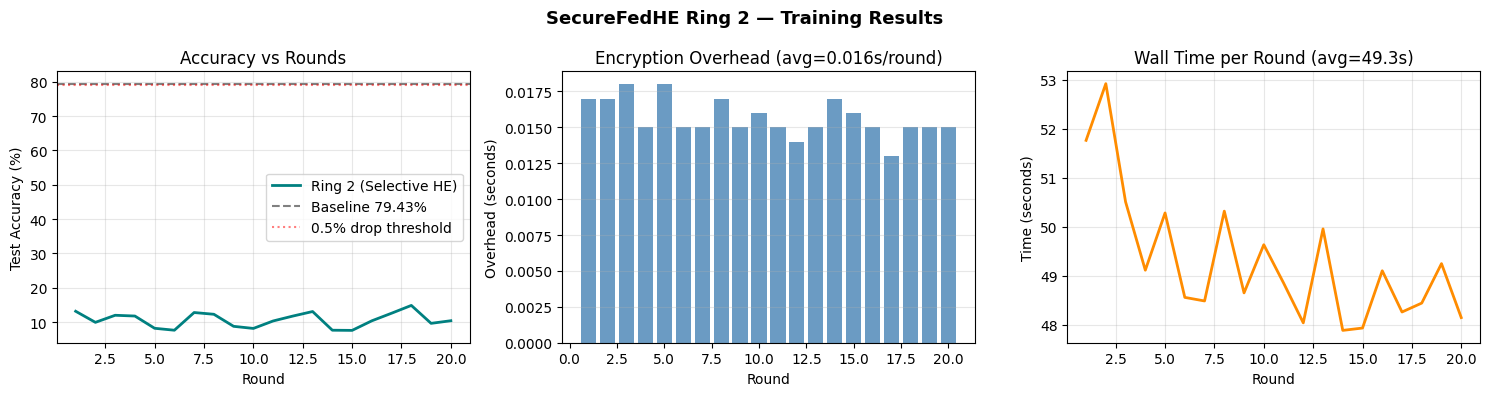


✓ Plot saved to /content/drive/MyDrive/SecureFedHE/evaluation/logs/ring2_results.png

── Summary Table (use in paper Table 2) ─────────────────────────
  Final test accuracy   : 10.40%
  Best test accuracy    : 14.86%
  Avg enc overhead/round: 0.0157s
  Avg wall time/round   : 49.30s
  Avg comm bytes/round  : 24270.5 KB
  DP privacy budget ε   : 2.0


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(CONFIG['log_path'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('SecureFedHE Ring 2 — Training Results', fontsize=13, fontweight='bold')

# Plot 1: Accuracy curve
axes[0].plot(df['round_num'], df['eval_acc']*100, 'teal', linewidth=2, label='Ring 2 (Selective HE)')
axes[0].axhline(CONFIG['baseline_acc'], color='gray', linestyle='--', label=f'Baseline {CONFIG["baseline_acc"]}%')
axes[0].axhline(CONFIG['baseline_acc']-0.5, color='red', linestyle=':', alpha=0.5, label='0.5% drop threshold')
axes[0].set_xlabel('Round'); axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Accuracy vs Rounds'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Plot 2: Encryption overhead per round
axes[1].bar(df['round_num'], df['enc_overhead_s'], color='steelblue', alpha=0.8)
axes[1].set_xlabel('Round'); axes[1].set_ylabel('Overhead (seconds)')
axes[1].set_title(f'Encryption Overhead (avg={df["enc_overhead_s"].mean():.3f}s/round)')
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Wall time per round
axes[2].plot(df['round_num'], df['wall_time_s'], color='darkorange', linewidth=2)
axes[2].set_xlabel('Round'); axes[2].set_ylabel('Time (seconds)')
axes[2].set_title(f'Wall Time per Round (avg={df["wall_time_s"].mean():.1f}s)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plot_path = f'{SAVE_DIR}/ring2_results.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✓ Plot saved to {plot_path}')

# Summary table
print('\n── Summary Table (use in paper Table 2) ─────────────────────────')
print(f"  Final test accuracy   : {df['eval_acc'].iloc[-1]*100:.2f}%")
print(f"  Best test accuracy    : {best_acc*100:.2f}%")
print(f"  Avg enc overhead/round: {df['enc_overhead_s'].mean():.4f}s")
print(f"  Avg wall time/round   : {df['wall_time_s'].mean():.2f}s")
print(f"  Avg comm bytes/round  : {df['comm_bytes'].mean()/1024:.1f} KB")
print(f"  DP privacy budget ε   : {CONFIG['dp_epsilon']}")

## Cell 9 — Privacy-Utility Trade-off Experiment
Run 3 epsilon values and compare. This becomes **Figure 2** in your paper.

⚠️ This runs 3 × 20 = 60 rounds total — takes ~10–15 minutes.

In [ ]:
epsilon_values = [10.0, 2.0, 1.0]  # weak → moderate → strong privacy
epsilon_results = {}

for eps in epsilon_values:
    print(f'\n── Running ε={eps} ────────────────────────────────────────────')
    model_eps = SimpleCNN().to(device)
    rng_eps   = np.random.default_rng(CONFIG['seed'])
    accs = []

    for rnd in range(1, CONFIG['rounds']+1):
        gp = get_params(model_eps)
        enc_list, plist, szs = [], [], []
        for cid in range(CONFIG['num_clients']):
            set_params(model_eps, gp)
            lm = copy.deepcopy(model_eps).to(device)
            lm.train()
            opt = torch.optim.SGD(lm.parameters(), lr=CONFIG['lr'], momentum=0.9)
            crit = nn.CrossEntropyLoss()
            for _ in range(CONFIG['local_epochs']):
                for x,y in train_loaders[cid]:
                    x,y=x.to(device),y.to(device)
                    opt.zero_grad(); out=lm(x)
                    crit(out,y).backward(); opt.step()
            ap = add_dp_noise(get_params(lm), epsilon=eps,
                delta=CONFIG['dp_delta'], sensitivity=CONFIG['dp_sensitivity'])
            enc, sh = encrypt_fc2(ap, HE_CTX)
            enc_list.append(enc)
            plist.append({k:v for k,v in ap.items() if k not in ('fc2.weight','fc2.bias')})
            szs.append(len(train_loaders[cid].dataset))
        agg_enc = aggregate_encrypted_fc2(enc_list, szs)
        dec = decrypt_fc2(agg_enc, sh)
        tw=sum(szs); ws=[s/tw for s in szs]
        ap2={}
        for key in plist[0]:
            stk=np.stack([p[key] for p in plist])
            w=np.array(ws).reshape([-1]+[1]*(stk.ndim-1))
            ap2[key]=(stk*w).sum(axis=0)
        model_eps.load_state_dict(
            {k:torch.tensor(v,dtype=torch.float32) for k,v in {**ap2,**dec}.items()})
        _, acc = compute_accuracy(model_eps, test_loader, device)
        accs.append(acc)
        print(f'  Round {rnd:02d} | acc={acc*100:.2f}%', end='\r')

    epsilon_results[eps] = accs
    print(f'  ε={eps:<5} | Final acc={accs[-1]*100:.2f}% | Best={max(accs)*100:.2f}%')

# Plot privacy-utility curve
plt.figure(figsize=(8,4))
colors = ['green','teal','red']
for (eps,accs),col in zip(epsilon_results.items(), colors):
    plt.plot(range(1,CONFIG['rounds']+1), [a*100 for a in accs],
             label=f'ε={eps}', color=col, linewidth=2)
plt.axhline(CONFIG['baseline_acc'], color='gray', linestyle='--', label='Baseline (no DP)')
plt.xlabel('Round'); plt.ylabel('Test Accuracy (%)')
plt.title('Privacy-Utility Trade-off: DP ε vs Accuracy')
plt.legend(); plt.grid(alpha=0.3)
plot_path2 = f'{SAVE_DIR}/privacy_utility_tradeoff.png'
plt.savefig(plot_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✓ Privacy-utility plot saved to {plot_path2}')


── Running ε=10.0 ────────────────────────────────────────────
  ε=10.0  | Final acc=8.19% | Best=10.77%

── Running ε=2.0 ────────────────────────────────────────────
  ε=2.0   | Final acc=10.58% | Best=19.55%

── Running ε=1.0 ────────────────────────────────────────────


## Cell 10 — Download Results
Download the metrics CSV and plots directly from Colab.

In [ ]:
from google.colab import files

print('Files saved to Google Drive:')
for f in [CONFIG['log_path'], CONFIG['weights_path'],
          f'{SAVE_DIR}/ring2_results.png',
          f'{SAVE_DIR}/privacy_utility_tradeoff.png']:
    if os.path.exists(f):
        size = os.path.getsize(f)/1024
        print(f'  ✓ {f.split("/")[-1]:<40} ({size:.1f} KB)')

print('\nDownload metrics CSV directly:')
files.download(CONFIG['log_path'])